# AI Face Recognition & Biometric Verification System

## Project Objective

The objective of this project is to design and evaluate a deep learning-based biometric recognition system capable of performing face verification (1:1 matching) and face identification (1:N matching).

The system uses transfer learning with ResNet18 to extract deep facial embeddings and cosine similarity to compare facial representations. The project also evaluates subject-independent generalization, PCA-based dimensionality reduction, and score-level fusion using ResNet18 and MobileNetV2.

## Dataset

This project uses the Georgia Tech Face Database, containing facial images with variations in pose, expression, scale, and lighting conditions.

The dataset is organized by subject identity and is used to evaluate both subject-dependent and subject-independent biometric recognition scenarios.

## Technical Approach

1. Load and preprocess facial images.
2. Fine-tune ResNet18 using transfer learning.
3. Extract 512-dimensional facial embeddings.
4. Perform face verification using cosine similarity.
5. Perform face identification using gallery-probe matching.
6. Evaluate the model using ROC-AUC, EER, TAR@FAR, and Rank-based accuracy.
7. Apply PCA for dimensionality reduction.
8. Evaluate score-level fusion using ResNet18 and MobileNetV2.

## 1. Dataset Setup and Extraction

The Georgia Tech Face Database is uploaded and extracted into the Colab environment. The dataset directory structure is then inspected to identify subject folders and prepare the data for preprocessing.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving gt_db.zip to gt_db.zip


In [ ]:
import zipfile
import os

zip_path = "gt_db.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [ ]:
os.listdir("/content/dataset")

['gt_db']

In [ ]:
import os

base_path = "/content/dataset/gt_db"

subjects = os.listdir(base_path)

print("Number of subject folders:", len(subjects))
print(subjects[:5])

Number of subject folders: 50
['s07', 's45', 's03', 's37', 's38']


## 2. Dataset Exploration

The dataset structure is inspected to understand the number of subject identities and facial images available. Sample subject directories are reviewed before preparing the training and testing datasets.

In [ ]:
sample_subject = subjects[0]

sample_path = os.path.join(base_path, sample_subject)

images = os.listdir(sample_path)

print(images)

['01.jpg', '15.jpg', '09.jpg', '02.jpg', '03.jpg', '13.jpg', '11.jpg', '14.jpg', '08.jpg', '12.jpg', '06.jpg', '05.jpg', '07.jpg', '04.jpg', '10.jpg']


In [ ]:
import os

base_path = "/content/dataset/gt_db"

subjects = sorted(os.listdir(base_path))

for subject in subjects[:3]:
    image_files = sorted(os.listdir(os.path.join(base_path, subject)))
    print(subject, image_files)

s01 ['01.jpg', '02.jpg', '03.jpg', '04.jpg', '05.jpg', '06.jpg', '07.jpg', '08.jpg', '09.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg']
s02 ['01.jpg', '02.jpg', '03.jpg', '04.jpg', '05.jpg', '06.jpg', '07.jpg', '08.jpg', '09.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg']
s03 ['01.jpg', '02.jpg', '03.jpg', '04.jpg', '05.jpg', '06.jpg', '07.jpg', '08.jpg', '09.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg']


## 3. Train-Test Data Preparation

Facial images are organized into training and testing samples based on subject identity. The resulting data split is used to train the classification model and evaluate biometric recognition performance.

In [ ]:
train_samples = []
test_samples = []

for label, subject in enumerate(subjects):

    subject_path = os.path.join(base_path, subject)

    images = sorted(os.listdir(subject_path))

    # First 10 for training
    train_imgs = images[:10]

    # Last 5 for testing
    test_imgs = images[10:]

    for img in train_imgs:
        train_samples.append(
            (os.path.join(subject_path, img), label)
        )

    for img in test_imgs:
        test_samples.append(
            (os.path.join(subject_path, img), label)
        )

print("Train samples:", len(train_samples))
print("Test samples:", len(test_samples))
print(train_samples[:3])
print(test_samples[:3])

Train samples: 500
Test samples: 251
[('/content/dataset/gt_db/s01/01.jpg', 0), ('/content/dataset/gt_db/s01/02.jpg', 0), ('/content/dataset/gt_db/s01/03.jpg', 0)]
[('/content/dataset/gt_db/s01/11.jpg', 0), ('/content/dataset/gt_db/s01/12.jpg', 0), ('/content/dataset/gt_db/s01/13.jpg', 0)]


In [ ]:
for subject in subjects:
    subject_path = os.path.join(base_path, subject)

    images = sorted(os.listdir(subject_path))

    if len(images) != 15:
        print(subject, len(images), images)

s33 16 ['01.jpg', '02.jpg', '03.jpg', '04.jpg', '05.jpg', '06.jpg', '07.jpg', '08.jpg', '09.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg', 'pspbrwse.jbf']


In [ ]:
train_samples = []
test_samples = []

for label, subject in enumerate(subjects):

    subject_path = os.path.join(base_path, subject)

    images = sorted([
        img for img in os.listdir(subject_path)
        if img.endswith(".jpg")
    ])

    train_imgs = images[:10]
    test_imgs = images[10:]

    for img in train_imgs:
        train_samples.append(
            (os.path.join(subject_path, img), label)
        )

    for img in test_imgs:
        test_samples.append(
            (os.path.join(subject_path, img), label)
        )

print("Train samples:", len(train_samples))
print("Test samples:", len(test_samples))

Train samples: 500
Test samples: 250


## 4. Custom Dataset and DataLoader

A custom PyTorch Dataset class is used to load facial images and identity labels. Image transformations are applied during data loading, and PyTorch DataLoaders are created to process training and testing samples in batches.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class FaceDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

train_dataset = FaceDataset(train_samples, transform=transform)
test_dataset = FaceDataset(test_samples, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 16
Test batches: 8


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using:", device)

model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 50)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

Using: cuda


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f} "
        f"Train Acc: {train_acc:.2f}%"
    )

Epoch [1/10] Loss: 2.7048 Train Acc: 43.00%
Epoch [2/10] Loss: 0.7909 Train Acc: 96.80%
Epoch [3/10] Loss: 0.2574 Train Acc: 99.60%
Epoch [4/10] Loss: 0.1145 Train Acc: 100.00%
Epoch [5/10] Loss: 0.0644 Train Acc: 100.00%
Epoch [6/10] Loss: 0.0438 Train Acc: 100.00%
Epoch [7/10] Loss: 0.0363 Train Acc: 100.00%
Epoch [8/10] Loss: 0.0264 Train Acc: 100.00%
Epoch [9/10] Loss: 0.0226 Train Acc: 100.00%
Epoch [10/10] Loss: 0.0202 Train Acc: 100.00%


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total

print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 98.40%


In [ ]:
import numpy as np

feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

def extract_features(loader):
    features = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            feats = feature_extractor(images)
            feats = feats.view(feats.size(0), -1)

            features.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())

    features = np.vstack(features)
    labels_list = np.concatenate(labels_list)

    return features, labels_list

test_features, test_labels = extract_features(test_loader)

print("Feature shape:", test_features.shape)
print("Labels shape:", test_labels.shape)

Feature shape: (250, 512)
Labels shape: (250,)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

genuine_scores = []
impostor_scores = []

for i in range(len(test_features)):
    for j in range(i + 1, len(test_features)):

        score = cosine_similarity(
            test_features[i].reshape(1, -1),
            test_features[j].reshape(1, -1)
        )[0][0]

        if test_labels[i] == test_labels[j]:
            genuine_scores.append(score)
        else:
            impostor_scores.append(score)

genuine_scores = np.array(genuine_scores)
impostor_scores = np.array(impostor_scores)

print("Genuine scores:", len(genuine_scores))
print("Impostor scores:", len(impostor_scores))

print("Genuine mean:", genuine_scores.mean())
print("Impostor mean:", impostor_scores.mean())

Genuine scores: 500
Impostor scores: 30625
Genuine mean: 0.9670007
Impostor mean: 0.505156


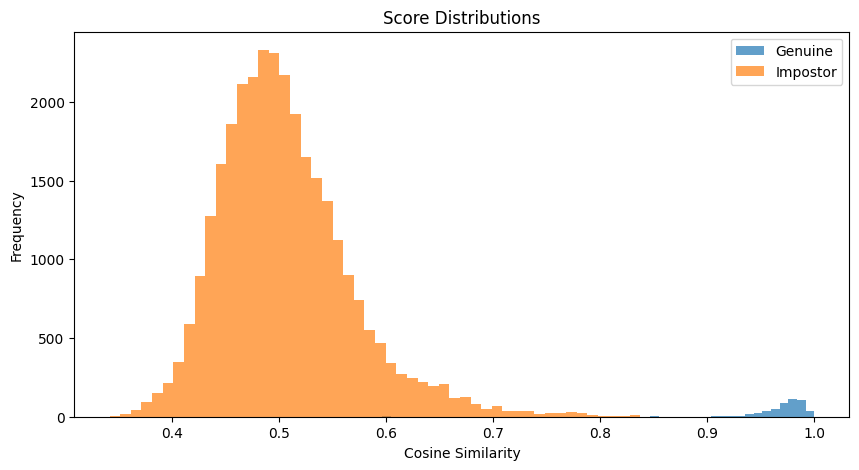

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    genuine_scores,
    bins=50,
    alpha=0.7,
    label="Genuine"
)

plt.hist(
    impostor_scores,
    bins=50,
    alpha=0.7,
    label="Impostor"
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.title("Score Distributions")

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

scores = np.concatenate([genuine_scores, impostor_scores])

labels = np.concatenate([
    np.ones(len(genuine_scores)),
    np.zeros(len(impostor_scores))
])

fpr, tpr, thresholds = roc_curve(labels, scores)

roc_auc = auc(fpr, tpr)

print("ROC AUC:", roc_auc)

ROC AUC: 0.999501518367347


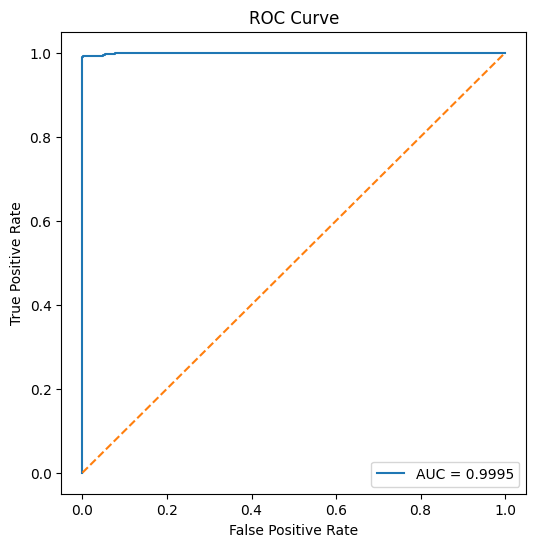

In [ ]:
plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
genuine_mean = np.mean(genuine_scores)
impostor_mean = np.mean(impostor_scores)

genuine_std = np.std(genuine_scores)
impostor_std = np.std(impostor_scores)

d_prime = abs(genuine_mean - impostor_mean) / np.sqrt(
    (genuine_std**2 + impostor_std**2) / 2
)

print("d-prime:", d_prime)

d-prime: 8.834326


#Rank-1 and Rank-3 Identification

In [ ]:
rank1_success = 0
rank3_success = 0

unique_labels = np.unique(test_labels)

for label in unique_labels:

    idxs = np.where(test_labels == label)[0]

    probe_idx = idxs[0]
    gallery_idxs = np.delete(np.arange(len(test_labels)), probe_idx)

    probe_feature = test_features[probe_idx].reshape(1, -1)
    gallery_features = test_features[gallery_idxs]

    similarities = cosine_similarity(
        probe_feature,
        gallery_features
    )[0]

    sorted_indices = np.argsort(similarities)[::-1]

    top1_label = test_labels[gallery_idxs[sorted_indices[0]]]
    top3_labels = test_labels[gallery_idxs[sorted_indices[:3]]]

    if top1_label == label:
        rank1_success += 1

    if label in top3_labels:
        rank3_success += 1

rank1_rate = rank1_success / len(unique_labels)
rank3_rate = rank3_success / len(unique_labels)

print(f"Rank-1 Identification Rate: {rank1_rate * 100:.2f}%")
print(f"Rank-3 Identification Rate: {rank3_rate * 100:.2f}%")

Rank-1 Identification Rate: 98.00%
Rank-3 Identification Rate: 98.00%


In [ ]:
fnr = 1 - tpr
eer_index = np.nanargmin(np.abs(fpr - fnr))
eer_threshold = thresholds[eer_index]

print("EER threshold:", eer_threshold)
print("FPR at EER:", fpr[eer_index])
print("FNR at EER:", fnr[eer_index])

EER threshold: 0.8142122
FPR at EER: 0.0005224489795918367
FNR at EER: 0.008000000000000007


In [ ]:
rank1_success = 0
rank1_possible = 0

rank3_success = 0
rank3_possible = 0

for label in unique_labels:

    idxs = np.where(test_labels == label)[0]

    probe_idx = idxs[0]

    gallery_idxs = np.delete(
        np.arange(len(test_labels)),
        probe_idx
    )

    probe_feature = test_features[probe_idx].reshape(1, -1)

    gallery_features = test_features[gallery_idxs]

    similarities = cosine_similarity(
        probe_feature,
        gallery_features
    )[0]

    sorted_indices = np.argsort(similarities)[::-1]

    sorted_scores = similarities[sorted_indices]

    sorted_labels = test_labels[
        gallery_idxs[sorted_indices]
    ]

    # ---------- Rank 1 ----------

    if sorted_scores[0] >= eer_threshold:

        rank1_possible += 1

        if sorted_labels[0] == label:
            rank1_success += 1

    # ---------- Rank 3 ----------

    valid_top3 = []

    for k in range(3):

        if sorted_scores[k] >= eer_threshold:
            valid_top3.append(sorted_labels[k])

    if len(valid_top3) > 0:

        rank3_possible += 1

        if label in valid_top3:
            rank3_success += 1

print("Thresholded Rank-1:",
      rank1_success / rank1_possible)

print("Thresholded Rank-3:",
      rank3_success / rank3_possible)

print("Rank-1 possible cases:",
      rank1_possible)

print("Rank-3 possible cases:",
      rank3_possible)

Thresholded Rank-1: 1.0
Thresholded Rank-3: 1.0
Rank-1 possible cases: 49
Rank-3 possible cases: 49


## 10. Subject-Independent Evaluation

A subject-independent evaluation protocol is prepared to assess biometric performance on unseen identities.

The dataset is separated by identity, with subjects 1 through 40 assigned to the training set and subjects 41 through 50 assigned to the evaluation set. This identity-disjoint split ensures that individuals in the evaluation set are not included in the training subset.

The experiment is used to study the generalization of learned facial representations to previously unseen identities.

In [ ]:
#Next do subject-independent protocol:
si_train_samples = []
si_test_samples = []

for subject in subjects:
    subject_num = int(subject[1:])

    subject_path = os.path.join(base_path, subject)

    images = sorted([
        img for img in os.listdir(subject_path)
        if img.endswith(".jpg")
    ])

    if subject_num <= 40:
        for img in images:
            si_train_samples.append(
                (os.path.join(subject_path, img), subject_num - 1)
            )
    else:
        for img in images:
            si_test_samples.append(
                (os.path.join(subject_path, img), subject_num - 41)
            )

print("Subject-independent train samples:", len(si_train_samples))
print("Subject-independent test samples:", len(si_test_samples))

Subject-independent train samples: 600
Subject-independent test samples: 150


In [ ]:
si_train_dataset = FaceDataset(si_train_samples, transform=transform)
si_test_dataset = FaceDataset(si_test_samples, transform=transform)

si_train_loader = DataLoader(
    si_train_dataset,
    batch_size=32,
    shuffle=True
)

si_test_loader = DataLoader(
    si_test_dataset,
    batch_size=32,
    shuffle=False
)

print("SI train batches:", len(si_train_loader))
print("SI test batches:", len(si_test_loader))

SI train batches: 19
SI test batches: 5


## 5. ResNet18 Transfer Learning and Model Training

A pretrained ResNet18 convolutional neural network is adapted for facial identity classification using transfer learning. The final classification layer is modified to match the number of subject identities in the dataset, and the model is fine-tuned using the prepared facial image samples.

In [ ]:
si_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = si_model.fc.in_features
si_model.fc = nn.Linear(num_features, 40)

si_model = si_model.to(device)

si_criterion = nn.CrossEntropyLoss()
si_optimizer = optim.Adam(si_model.parameters(), lr=0.0001)

print(si_model.fc)

Linear(in_features=512, out_features=40, bias=True)


In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    si_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in si_train_loader:
        images = images.to(device)
        labels = labels.to(device)

        si_optimizer.zero_grad()

        outputs = si_model(images)
        loss = si_criterion(outputs, labels)

        loss.backward()
        si_optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {running_loss/len(si_train_loader):.4f} "
        f"Train Acc: {train_acc:.2f}%"
    )

Epoch [1/10] Loss: 2.0867 Train Acc: 63.83%
Epoch [2/10] Loss: 0.4092 Train Acc: 98.33%
Epoch [3/10] Loss: 0.1166 Train Acc: 99.83%
Epoch [4/10] Loss: 0.0551 Train Acc: 100.00%
Epoch [5/10] Loss: 0.0346 Train Acc: 100.00%
Epoch [6/10] Loss: 0.0264 Train Acc: 100.00%
Epoch [7/10] Loss: 0.0213 Train Acc: 100.00%
Epoch [8/10] Loss: 0.0187 Train Acc: 100.00%
Epoch [9/10] Loss: 0.0145 Train Acc: 100.00%
Epoch [10/10] Loss: 0.0125 Train Acc: 100.00%


## 6. Deep Facial Feature Extraction

The trained ResNet18 model is converted into a feature extractor by removing the final classification layer. The resulting network generates a 512-dimensional embedding for each facial image.

These embeddings provide a numerical representation of facial characteristics and are used for biometric similarity comparison.

In [ ]:
si_feature_extractor = torch.nn.Sequential(*list(si_model.children())[:-1])
si_feature_extractor = si_feature_extractor.to(device)
si_feature_extractor.eval()

def extract_features_from_model(loader, extractor):
    features = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            feats = extractor(images)
            feats = feats.view(feats.size(0), -1)

            features.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())

    return np.vstack(features), np.concatenate(labels_list)

si_test_features, si_test_labels = extract_features_from_model(
    si_test_loader,
    si_feature_extractor
)

print("SI feature shape:", si_test_features.shape)
print("SI labels shape:", si_test_labels.shape)

SI feature shape: (150, 512)
SI labels shape: (150,)


## 7. Face Verification Using Cosine Similarity

Cosine similarity is used to compare pairs of facial embeddings. Genuine scores are generated from image pairs belonging to the same identity, while impostor scores are generated from different identities.

The similarity score distributions are analyzed to evaluate how effectively the system separates genuine users from impostors.

In [ ]:
si_genuine_scores = []
si_impostor_scores = []

for i in range(len(si_test_features)):
    for j in range(i + 1, len(si_test_features)):

        score = cosine_similarity(
            si_test_features[i].reshape(1, -1),
            si_test_features[j].reshape(1, -1)
        )[0][0]

        if si_test_labels[i] == si_test_labels[j]:
            si_genuine_scores.append(score)
        else:
            si_impostor_scores.append(score)

si_genuine_scores = np.array(si_genuine_scores)
si_impostor_scores = np.array(si_impostor_scores)

print("SI Genuine scores:", len(si_genuine_scores))
print("SI Impostor scores:", len(si_impostor_scores))

print("SI Genuine mean:", si_genuine_scores.mean())
print("SI Impostor mean:", si_impostor_scores.mean())

SI Genuine scores: 1050
SI Impostor scores: 10125
SI Genuine mean: 0.8886671
SI Impostor mean: 0.6900773


## 8. Verification Performance Evaluation

The biometric verification system is evaluated using ROC curves, Area Under the Curve (AUC), Equal Error Rate (EER), and genuine-impostor score separation.

These metrics measure the system's ability to correctly verify genuine identities while minimizing false acceptance of impostors.

In [ ]:
si_scores = np.concatenate([
    si_genuine_scores,
    si_impostor_scores
])

si_labels = np.concatenate([
    np.ones(len(si_genuine_scores)),
    np.zeros(len(si_impostor_scores))
])

si_fpr, si_tpr, si_thresholds = roc_curve(
    si_labels,
    si_scores
)

si_auc = auc(si_fpr, si_tpr)

print("SI ROC AUC:", si_auc)

SI ROC AUC: 0.8986666666666667


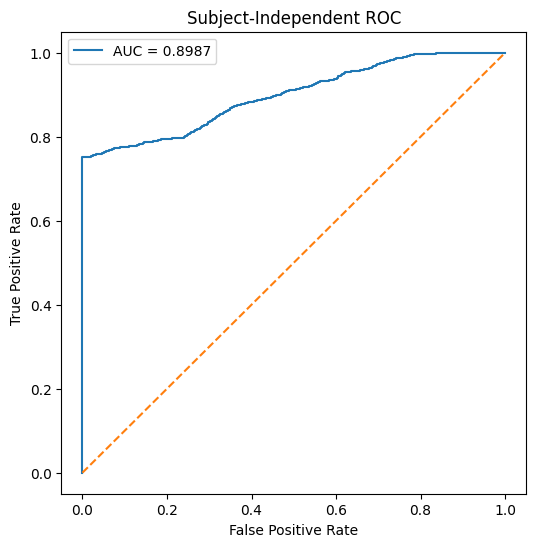

In [ ]:
plt.figure(figsize=(6,6))

plt.plot(
    si_fpr,
    si_tpr,
    label=f"AUC = {si_auc:.4f}"
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Subject-Independent ROC")

plt.legend()

plt.show()

In [ ]:
si_genuine_mean = np.mean(si_genuine_scores)
si_impostor_mean = np.mean(si_impostor_scores)

si_genuine_std = np.std(si_genuine_scores)
si_impostor_std = np.std(si_impostor_scores)

si_d_prime = abs(
    si_genuine_mean - si_impostor_mean
) / np.sqrt(
    (si_genuine_std**2 + si_impostor_std**2) / 2
)

print("SI d-prime:", si_d_prime)

SI d-prime: 2.2480278


## 11. PCA-Based Dimensionality Reduction

Principal Component Analysis (PCA) is applied to reduce the facial embedding dimensionality from 512 features to 128 principal components.

The reduced embeddings are evaluated using cosine similarity and ROC-AUC to study whether computational complexity can be reduced while preserving biometric recognition performance.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=128)

train_pca_features = pca.fit_transform(test_features)

print("Original shape:", test_features.shape)
print("PCA shape:", train_pca_features.shape)

explained = np.sum(pca.explained_variance_ratio_)

print("Explained variance:", explained)

Original shape: (250, 512)
PCA shape: (250, 128)
Explained variance: 0.99421906


In [ ]:
pca_genuine_scores = []
pca_impostor_scores = []

for i in range(len(train_pca_features)):
    for j in range(i + 1, len(train_pca_features)):

        score = cosine_similarity(
            train_pca_features[i].reshape(1, -1),
            train_pca_features[j].reshape(1, -1)
        )[0][0]

        if test_labels[i] == test_labels[j]:
            pca_genuine_scores.append(score)
        else:
            pca_impostor_scores.append(score)

pca_genuine_scores = np.array(pca_genuine_scores)
pca_impostor_scores = np.array(pca_impostor_scores)

print("PCA Genuine Mean:", pca_genuine_scores.mean())
print("PCA Impostor Mean:", pca_impostor_scores.mean())

PCA Genuine Mean: 0.9349905
PCA Impostor Mean: -0.019177627


In [ ]:
pca_scores = np.concatenate([
    pca_genuine_scores,
    pca_impostor_scores
])

pca_labels = np.concatenate([
    np.ones(len(pca_genuine_scores)),
    np.zeros(len(pca_impostor_scores))
])

pca_fpr, pca_tpr, _ = roc_curve(
    pca_labels,
    pca_scores
)

pca_auc = auc(pca_fpr, pca_tpr)

print("PCA ROC AUC:", pca_auc)

PCA ROC AUC: 0.9968996571428572


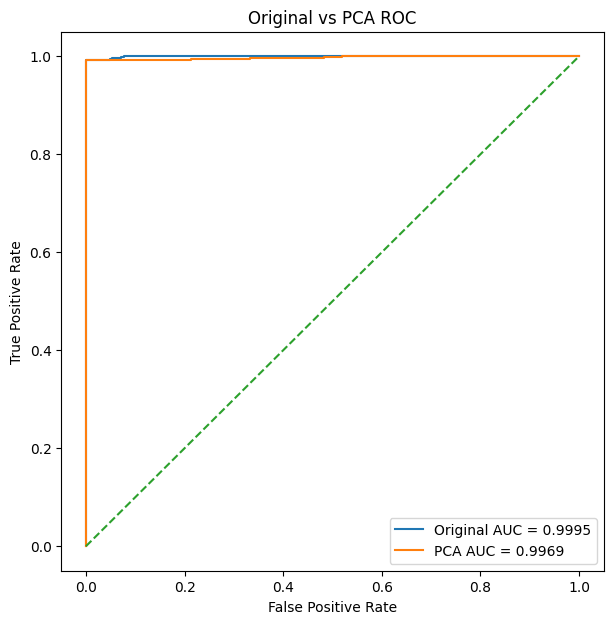

In [ ]:
plt.figure(figsize=(7,7))

plt.plot(
    fpr,
    tpr,
    label=f"Original AUC = {roc_auc:.4f}"
)

plt.plot(
    pca_fpr,
    pca_tpr,
    label=f"PCA AUC = {pca_auc:.4f}"
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Original vs PCA ROC")

plt.legend()

plt.show()

## 9. Rank-Based Face Identification

The system performs 1:N face identification by comparing a probe facial embedding against a gallery of candidate identities.

Rank-1 and Rank-3 accuracy are evaluated to determine whether the correct identity appears as the top match or within the top three similarity matches.

## 12. Cumulative Match Characteristic (CMC) Evaluation

A Cumulative Match Characteristic (CMC) curve is generated to evaluate identification performance across multiple rank positions.

The CMC curve measures the probability that the correct identity appears within the top-N ranked matches returned by the biometric identification system.

In [ ]:
max_rank = 20

cmc = np.zeros(max_rank)

for label in unique_labels:

    idxs = np.where(test_labels == label)[0]

    probe_idx = idxs[0]

    gallery_idxs = np.delete(
        np.arange(len(test_labels)),
        probe_idx
    )

    probe_feature = test_features[probe_idx].reshape(1, -1)

    gallery_features = test_features[gallery_idxs]

    similarities = cosine_similarity(
        probe_feature,
        gallery_features
    )[0]

    sorted_indices = np.argsort(similarities)[::-1]

    sorted_labels = test_labels[
        gallery_idxs[sorted_indices]
    ]

    correct_rank = np.where(sorted_labels == label)[0][0]

    if correct_rank < max_rank:
        cmc[correct_rank:] += 1

cmc = cmc / len(unique_labels)

print(cmc)

[0.98 0.98 0.98 0.98 0.98 0.98 0.98 0.98 0.98 0.98 0.98 0.98 0.98 1.
 1.   1.   1.   1.   1.   1.  ]


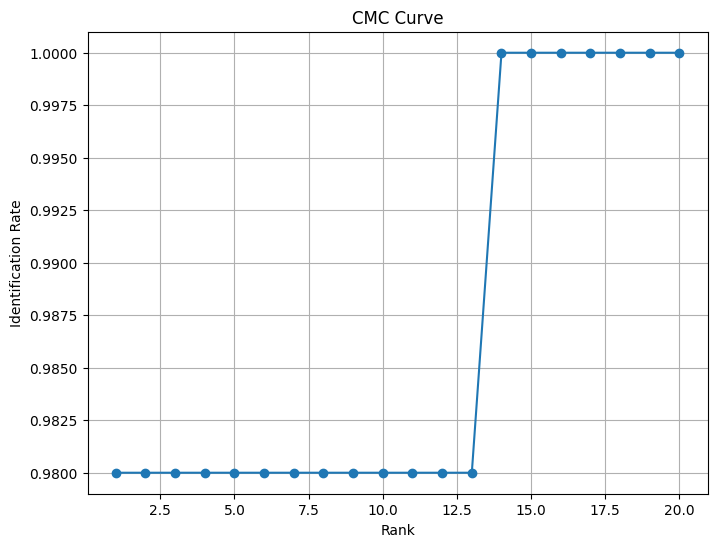

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(
    range(1, max_rank + 1),
    cmc,
    marker='o'
)

plt.xlabel("Rank")
plt.ylabel("Identification Rate")

plt.title("CMC Curve")

plt.grid(True)

plt.show()

## 13. MobileNetV2 Model Training and Feature Extraction

A pretrained MobileNetV2 model is adapted and fine-tuned for facial identity classification.

Deep facial features are extracted from the trained MobileNetV2 network to provide an alternative biometric representation for comparison and multi-model fusion.

In [ ]:
mobilenet = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.DEFAULT
)

mobilenet.classifier[1] = nn.Linear(
    mobilenet.last_channel,
    50
)

mobilenet = mobilenet.to(device)

mobile_criterion = nn.CrossEntropyLoss()

mobile_optimizer = optim.Adam(
    mobilenet.parameters(),
    lr=0.0001
)

print(mobilenet.classifier)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 120MB/s]

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=50, bias=True)
)


In [ ]:
num_epochs = 10

for epoch in range(num_epochs):

    mobilenet.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        mobile_optimizer.zero_grad()

        outputs = mobilenet(images)
        loss = mobile_criterion(outputs, labels)

        loss.backward()
        mobile_optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f} "
        f"Train Acc: {train_acc:.2f}%"
    )

Epoch [1/10] Loss: 3.7880 Train Acc: 14.20%
Epoch [2/10] Loss: 3.3720 Train Acc: 66.20%
Epoch [3/10] Loss: 2.9602 Train Acc: 88.80%
Epoch [4/10] Loss: 2.5525 Train Acc: 94.20%
Epoch [5/10] Loss: 2.1536 Train Acc: 95.20%
Epoch [6/10] Loss: 1.7886 Train Acc: 96.80%
Epoch [7/10] Loss: 1.4222 Train Acc: 97.80%
Epoch [8/10] Loss: 1.1060 Train Acc: 98.80%
Epoch [9/10] Loss: 0.8499 Train Acc: 99.60%
Epoch [10/10] Loss: 0.6525 Train Acc: 99.20%


In [ ]:
mobile_feature_extractor = mobilenet.features
mobile_feature_extractor = mobile_feature_extractor.to(device)
mobile_feature_extractor.eval()

def extract_mobilenet_features(loader):
    features = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            feats = mobile_feature_extractor(images)
            feats = torch.nn.functional.adaptive_avg_pool2d(feats, (1, 1))
            feats = feats.view(feats.size(0), -1)

            features.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())

    return np.vstack(features), np.concatenate(labels_list)

mobile_test_features, mobile_test_labels = extract_mobilenet_features(test_loader)

print("MobileNet feature shape:", mobile_test_features.shape)
print("MobileNet labels shape:", mobile_test_labels.shape)

MobileNet feature shape: (250, 1280)
MobileNet labels shape: (250,)


## 14. Score-Level Model Fusion

Score-level fusion is performed by combining cosine similarity scores generated from ResNet18 and MobileNetV2 facial embeddings.

The similarity scores from both models are averaged to generate a fused biometric score. Fusion performance is evaluated using ROC-AUC and compared with the individual model and PCA-based results.

In [ ]:
fusion_genuine_scores = []
fusion_impostor_scores = []

for i in range(len(test_features)):
    for j in range(i + 1, len(test_features)):

        resnet_score = cosine_similarity(
            test_features[i].reshape(1, -1),
            test_features[j].reshape(1, -1)
        )[0][0]

        mobile_score = cosine_similarity(
            mobile_test_features[i].reshape(1, -1),
            mobile_test_features[j].reshape(1, -1)
        )[0][0]

        fusion_score = (resnet_score + mobile_score) / 2

        if test_labels[i] == test_labels[j]:
            fusion_genuine_scores.append(fusion_score)
        else:
            fusion_impostor_scores.append(fusion_score)

fusion_genuine_scores = np.array(fusion_genuine_scores)
fusion_impostor_scores = np.array(fusion_impostor_scores)

print("Fusion Genuine Mean:", fusion_genuine_scores.mean())
print("Fusion Impostor Mean:", fusion_impostor_scores.mean())

Fusion Genuine Mean: 0.9297983
Fusion Impostor Mean: 0.40398753


In [ ]:
fusion_scores = np.concatenate([
    fusion_genuine_scores,
    fusion_impostor_scores
])

fusion_labels = np.concatenate([
    np.ones(len(fusion_genuine_scores)),
    np.zeros(len(fusion_impostor_scores))
])

fusion_fpr, fusion_tpr, _ = roc_curve(
    fusion_labels,
    fusion_scores
)

fusion_auc = auc(fusion_fpr, fusion_tpr)

print("Fusion ROC AUC:", fusion_auc)

Fusion ROC AUC: 0.9988815020408163


## 15. Comparative ROC Analysis

ROC curves are compared across the original ResNet18 embeddings, PCA-reduced embeddings, and the ResNet18-MobileNetV2 fused biometric scores.

This comparison evaluates the trade-offs between the baseline deep embedding approach, dimensionality reduction, and multi-model score fusion.

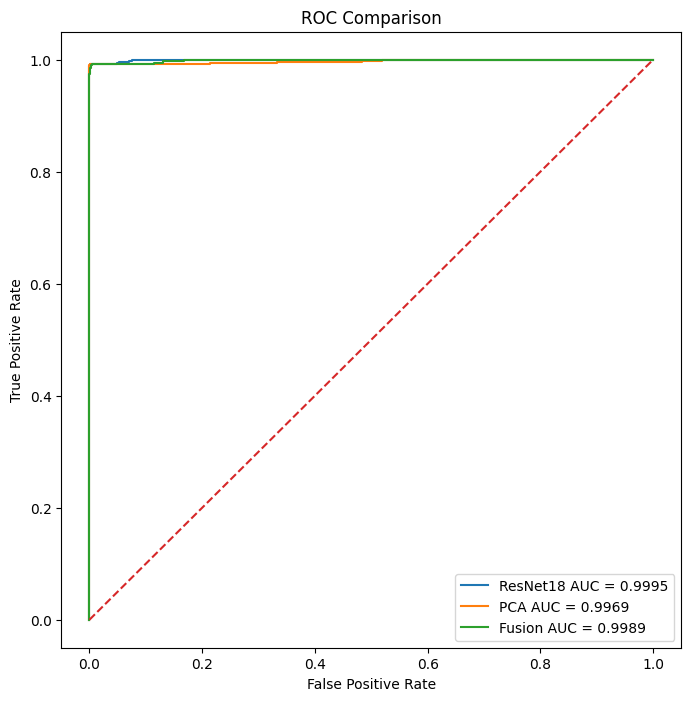

In [ ]:
plt.figure(figsize=(8,8))

plt.plot(
    fpr,
    tpr,
    label=f"ResNet18 AUC = {roc_auc:.4f}"
)

plt.plot(
    pca_fpr,
    pca_tpr,
    label=f"PCA AUC = {pca_auc:.4f}"
)

plt.plot(
    fusion_fpr,
    fusion_tpr,
    label=f"Fusion AUC = {fusion_auc:.4f}"
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Comparison")

plt.legend()

plt.show()